# 🎯 Customer Churn Prediction Model Training
## Mamina Baby Spa

Notebook ini digunakan untuk:
1. Load data dari PostgreSQL
2. Exploratory Data Analysis (EDA)
3. Feature Engineering & Selection
4. Model Training (XGBoost)
5. Model Evaluation
6. SHAP Explainability
7. Export Model untuk Production

---

## 1. Setup & Import Libraries

In [4]:
# Install dependencies jika belum ada
!pip install psycopg2-binary sqlalchemy pandas numpy scikit-learn xgboost shap matplotlib seaborn joblib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 472.8 kB/s eta 0:00:17
   -- ------------------------------------- 0.5/8.1 MB 472.8 kB/s eta 0:00:17
   --- ------------------------------------ 0.8/8.1 MB 479.9 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/8.1 MB 479.9 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/8.1 MB 479.9 kB/s eta 0:00:16
   ----- ---------------------------------- 1.0/8.1 MB 468.3 kB/s eta 0:00:16
   ----- ---------------------------------- 1.0/8.1 MB 468.3 kB/s eta 0:00:16
   ------ --------------------------------- 1.3/8.1 MB 476.8 kB/s eta 0:00:15
   ------ ---------------------

In [5]:
import sys
import socket

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Test basic socket connection
try:
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.settimeout(5)
    result = sock.connect_ex(('127.0.0.1', 5433))
    if result == 0:
        print("✅ Port 5433 is OPEN")
    else:
        print(f"❌ Port 5433 is CLOSED (error code: {result})")
    sock.close()
except Exception as e:
    print(f"❌ Socket error: {e}")

Python executable: d:\coolyeah\Skripsi\Customer Analitycs (Mamina)\.venv\Scripts\python.exe
Python version: 3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]
✅ Port 5433 is OPEN


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Database
from sqlalchemy import create_engine, text

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

# Explainability
import shap

# Model Persistence
import joblib
import pickle

print("✅ Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP version: {shap.__version__}")

✅ Libraries imported successfully!
XGBoost version: 3.1.2
SHAP version: 0.50.0


## 2. Database Connection

In [9]:
# Konfigurasi Database - sesuaikan dengan .env backend
DB_CONFIG = {
    'host': '127.0.0.1',  # Gunakan IP address langsung
    'port': 5433,
    'database': 'maminaChurn_db',
    'user': 'postgres',
    'password': 'adamsafril234'  # Ganti dengan password Anda
}

DATABASE_URL = f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"

engine = create_engine(DATABASE_URL)

# Test connection
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1"))
        print("✅ Database connected successfully!")
except Exception as e:
    print(f"❌ Database connection failed: {e}")

✅ Database connected successfully!


## 3. Load Data dari Database

In [11]:
# Load Customer Features
query_features = """
SELECT 
    cf.customer_id,
    cf.r_score,
    cf.f_score,
    cf.m_score,
    cf.tenure_days,
    cf.avg_sentiment_30,
    cf.neg_msg_count_30,
    cf.avg_response_secs,
    cf.intensity_7d,
    cf.created_at
FROM customer_features cf
WHERE cf.r_score IS NOT NULL
"""

df_features = pd.read_sql(query_features, engine)
print(f"✅ Loaded {len(df_features)} customer features")
df_features.head()

✅ Loaded 10 customer features


,customer_id,r_score,f_score,m_score,tenure_days,avg_sentiment_30,neg_msg_count_30,avg_response_secs,intensity_7d,created_at
0,d67dbc0b-f963-444f-a8c3-429e9a59bc47,4.946450,1.317711,4.731531,156,-0.172265,4,1044.0,8,2025-12-23 19:39:55.254879
1,492a635a-456d-47fb-a5c7-a8b32511e10b,3.672751,4.868751,2.533562,300,-0.302444,9,469.0,11,2025-12-23 19:39:55.259442
2,6a2ab0c2-7849-42f6-ab13-a4705714fbc9,3.112151,2.729115,2.037799,101,-0.078513,7,1482.0,13,2025-12-23 19:39:55.260484
3,1e30ba75-32ce-41f4-b8df-b556261ff76f,3.915016,4.157902,3.373583,175,-0.385733,3,1493.0,13,2025-12-23 19:39:55.261307
4,14377236-e7df-4930-8fbe-d7a642ad15fa,4.202884,2.420595,3.555885,236,0.655312,0,2771.0,7,2025-12-23 19:39:55.262065


In [13]:
# Load Customer Info
query_customers = """
SELECT 
    customer_id,
    name,
    is_active,
    created_at,
    last_seen_at
FROM customers
"""

df_customers = pd.read_sql(query_customers, engine)
print(f"✅ Loaded {len(df_customers)} customers")
df_customers.head()

✅ Loaded 10 customers


,customer_id,name,is_active,created_at,last_seen_at
0,d67dbc0b-f963-444f-a8c3-429e9a59bc47,Ibu Sari Wijaya,True,2025-08-20 02:39:55.098527,None
1,492a635a-456d-47fb-a5c7-a8b32511e10b,Ibu Dewi Lestari,True,2025-06-29 02:39:55.098678,None
2,6a2ab0c2-7849-42f6-ab13-a4705714fbc9,Ibu Rina Kusuma,True,2025-02-15 02:39:55.098736,None
3,1e30ba75-32ce-41f4-b8df-b556261ff76f,Ibu Maya Putri,True,2025-07-13 02:39:55.098778,None
4,14377236-e7df-4930-8fbe-d7a642ad15fa,Ibu Ani Handayani,True,2025-07-24 02:39:55.098815,None


In [14]:
# Merge data
df = df_features.merge(df_customers, on='customer_id', how='left')
print(f"✅ Merged dataset: {len(df)} rows")
df.info()

✅ Merged dataset: 10 rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        10 non-null     object        
 1   r_score            10 non-null     float64       
 2   f_score            10 non-null     float64       
 3   m_score            10 non-null     float64       
 4   tenure_days        10 non-null     int64         
 5   avg_sentiment_30   10 non-null     float64       
 6   neg_msg_count_30   10 non-null     int64         
 7   avg_response_secs  10 non-null     float64       
 8   intensity_7d       10 non-null     int64         
 9   created_at_x       10 non-null     datetime64[ns]
 10  name               10 non-null     object        
 11  is_active          10 non-null     bool          
 12  created_at_y       10 non-null     datetime64[ns]
 13  last_seen_at       0 non-null      object 

## 4. Define Churn Label

**Definisi Churn:**
- Customer dianggap churn jika tidak berkunjung dalam 90 hari terakhir
- Atau `is_active = False`

In [16]:
# Definisi churn - menggunakan kombinasi fitur karena last_seen_at kosong di seed data
# Untuk production, gunakan last_seen_at yang sebenarnya

def define_churn(row):
    """
    Define churn berdasarkan kombinasi fitur:
    - Sentiment negatif tinggi (avg_sentiment_30 < -0.2)
    - Banyak pesan negatif (neg_msg_count_30 > 5)
    - Response time lambat (avg_response_secs > 2000)
    - R-score rendah (recency buruk) + kombinasi lain
    """
    churn_score = 0
    
    # Faktor negatif (menambah risiko churn)
    if row['avg_sentiment_30'] < -0.2:
        churn_score += 1
    if row['neg_msg_count_30'] > 5:
        churn_score += 1
    if row['avg_response_secs'] > 2000:
        churn_score += 1
    if row['r_score'] < 2.5:
        churn_score += 1
    if row['f_score'] < 2.0:
        churn_score += 1
    
    # Faktor positif (mengurangi risiko churn)
    if row['avg_sentiment_30'] > 0.3:
        churn_score -= 1
    if row['f_score'] > 4.0:
        churn_score -= 1
    if row['intensity_7d'] > 8:
        churn_score -= 1
    
    # Threshold: churn jika score >= 2
    return 1 if churn_score >= 2 else 0

df['churn'] = df.apply(define_churn, axis=1)

print("\n📊 Churn Distribution:")
print(df['churn'].value_counts())
print(f"\nChurn Rate: {df['churn'].mean()*100:.2f}%")

# Tampilkan beberapa contoh
print("\n📋 Sample data dengan label churn:")
print(df[['name', 'avg_sentiment_30', 'neg_msg_count_30', 'r_score', 'f_score', 'churn']].head(10))


📊 Churn Distribution:
churn
0    8
1    2
Name: count, dtype: int64

Churn Rate: 20.00%

📋 Sample data dengan label churn:
                name  avg_sentiment_30  neg_msg_count_30   r_score   f_score  \
0    Ibu Sari Wijaya         -0.172265                 4  4.946450  1.317711   
1   Ibu Dewi Lestari         -0.302444                 9  3.672751  4.868751   
2    Ibu Rina Kusuma         -0.078513                 7  3.112151  2.729115   
3     Ibu Maya Putri         -0.385733                 3  3.915016  4.157902   
4  Ibu Ani Handayani          0.655312                 0  4.202884  2.420595   
5   Ibu Fitri Rahayu          0.328859                 3  3.230588  2.250559   
6  Ibu Linda Susanti         -0.002948                 5  2.514443  1.149235   
7   Ibu Wati Purnama          0.364139                 7  1.663200  1.798123   
8    Ibu Yuni Astuti          0.788213                 2  3.572410  2.256308   
9     Ibu Ratna Sari          0.094251                 5  4.664954  1.000616

## 5. Exploratory Data Analysis (EDA)

In [17]:
# Dataset overview
print("📊 Dataset Overview:")
print(f"Total samples: {len(df)}")
print(f"Features: {df.shape[1]}")
print(f"\nMissing values:")
print(df.isnull().sum())

📊 Dataset Overview:
Total samples: 10
Features: 15

Missing values:
customer_id           0
r_score               0
f_score               0
m_score               0
tenure_days           0
avg_sentiment_30      0
neg_msg_count_30      0
avg_response_secs     0
intensity_7d          0
created_at_x          0
name                  0
is_active             0
created_at_y          0
last_seen_at         10
churn                 0
dtype: int64


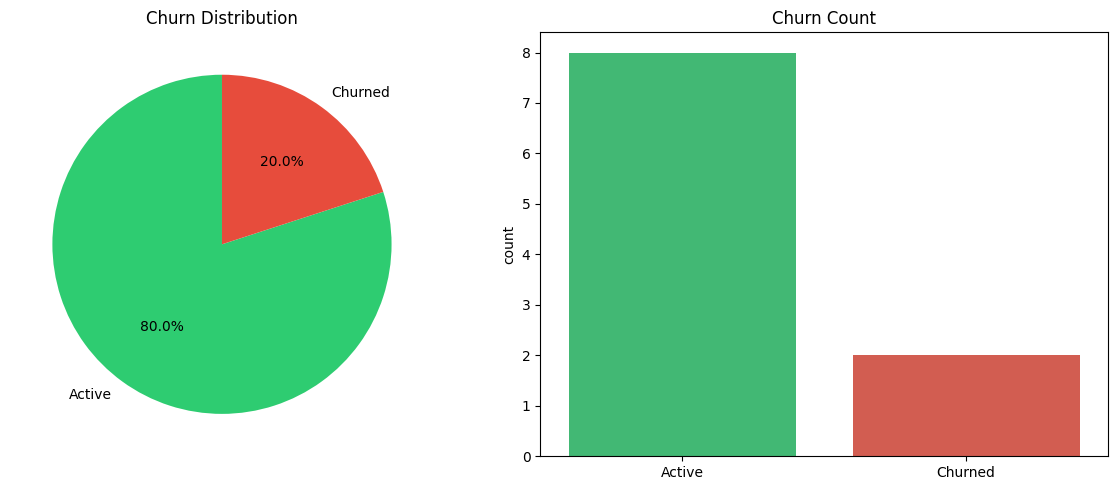

In [18]:
# Churn distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colors = ['#2ecc71', '#e74c3c']
labels = ['Active', 'Churned']
sizes = df['churn'].value_counts().sort_index()
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Churn Distribution')

# Bar chart
sns.countplot(data=df, x='churn', palette=colors, ax=axes[1])
axes[1].set_xticklabels(labels)
axes[1].set_title('Churn Count')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
# Feature distributions by churn status
feature_cols = ['r_score', 'f_score', 'm_score', 'tenure_days', 
                'avg_sentiment_30', 'neg_msg_count_30', 'avg_response_secs', 'intensity_7d']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    if col in df.columns:
        sns.boxplot(data=df, x='churn', y=col, palette=colors, ax=axes[i])
        axes[i].set_xticklabels(['Active', 'Churned'])
        axes[i].set_title(f'{col} by Churn Status')

plt.tight_layout()
plt.show()

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_cols = feature_cols + ['churn']
corr_matrix = df[correlation_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 6. Data Preprocessing

In [19]:
# Select features for model
FEATURE_COLUMNS = [
    'r_score',           # Recency score
    'f_score',           # Frequency score
    'm_score',           # Monetary score
    'tenure_days',       # Customer tenure
    'avg_sentiment_30',  # Average sentiment last 30 days
    'neg_msg_count_30',  # Negative message count last 30 days
    'avg_response_secs', # Average response time
    'intensity_7d'       # Message intensity last 7 days
]

# Prepare X and y
X = df[FEATURE_COLUMNS].copy()
y = df['churn'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (10, 8)
Target shape: (10,)


In [20]:
# Handle missing values
print("Missing values before:")
print(X.isnull().sum())

# Fill missing values with median
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)

print("\nMissing values after:")
print(X.isnull().sum())

Missing values before:
r_score              0
f_score              0
m_score              0
tenure_days          0
avg_sentiment_30     0
neg_msg_count_30     0
avg_response_secs    0
intensity_7d         0
dtype: int64

Missing values after:
r_score              0
f_score              0
m_score              0
tenure_days          0
avg_sentiment_30     0
neg_msg_count_30     0
avg_response_secs    0
intensity_7d         0
dtype: int64


In [21]:
# Train-Test Split
# Untuk data kecil (< 20 samples), tidak menggunakan stratify
if len(X) < 20:
    print("⚠️ Dataset kecil - menggunakan split tanpa stratify")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.3,  # 30% test untuk data kecil
        random_state=42
    )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42,
        stratify=y
    )

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate: {y_test.mean()*100:.2f}%")

⚠️ Dataset kecil - menggunakan split tanpa stratify
Training set: 7 samples
Test set: 3 samples

Training churn rate: 28.57%
Test churn rate: 0.00%


In [22]:
# Feature Scaling (untuk beberapa model)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled successfully!")

✅ Features scaled successfully!


## 7. Model Training - XGBoost

In [23]:
# Calculate class weights for imbalanced data
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
scale_pos_weight = class_weights[1] / class_weights[0]
print(f"Scale pos weight: {scale_pos_weight:.2f}")

Scale pos weight: 2.50


In [24]:
# XGBoost Model dengan hyperparameters yang sudah di-tune
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # Handle imbalanced
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train model
print("Training XGBoost model...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print("✅ Model training completed!")

Training XGBoost model...
✅ Model training completed!
✅ Model training completed!


In [25]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"\n📊 Cross-Validation Results (5-Fold):")
print(f"ROC-AUC scores: {cv_scores}")
print(f"Mean ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


📊 Cross-Validation Results (5-Fold):
ROC-AUC scores: [0.5 0.5 nan nan nan]
Mean ROC-AUC: nan (+/- nan)


## 8. Model Evaluation

In [26]:
# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("📊 Model Evaluation on Test Set:")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

📊 Model Evaluation on Test Set:
Accuracy:  0.6667
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
ROC-AUC:   nan


In [27]:
# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))


📋 Classification Report:
              precision    recall  f1-score   support

      Active       1.00      0.67      0.80         3
     Churned       0.00      0.00      0.00         0

    accuracy                           0.67         3
   macro avg       0.50      0.33      0.40         3
weighted avg       1.00      0.67      0.80         3



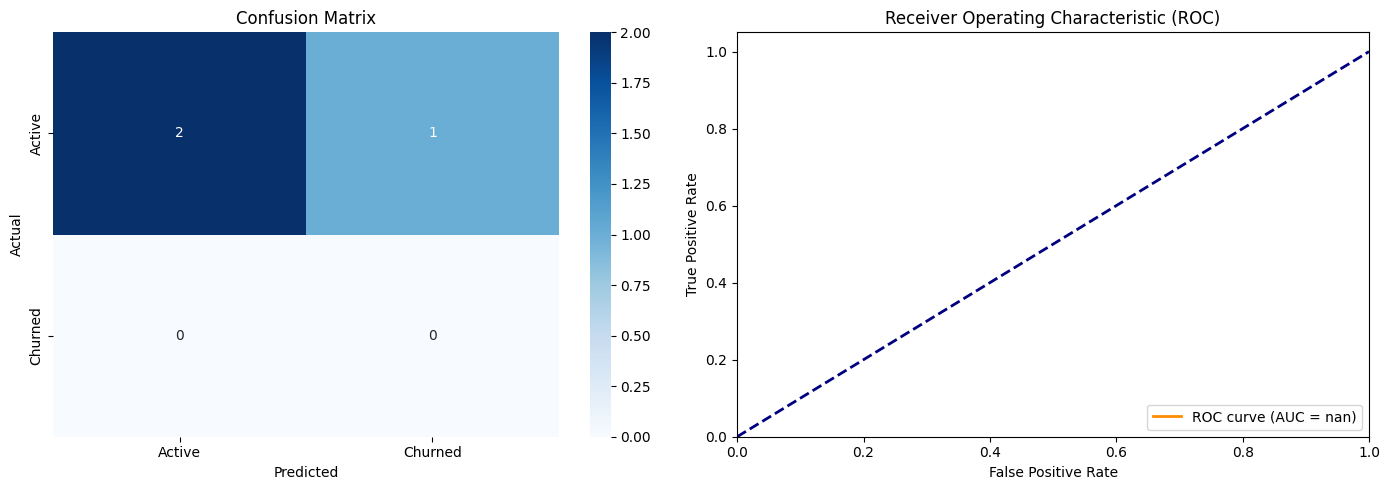

In [28]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

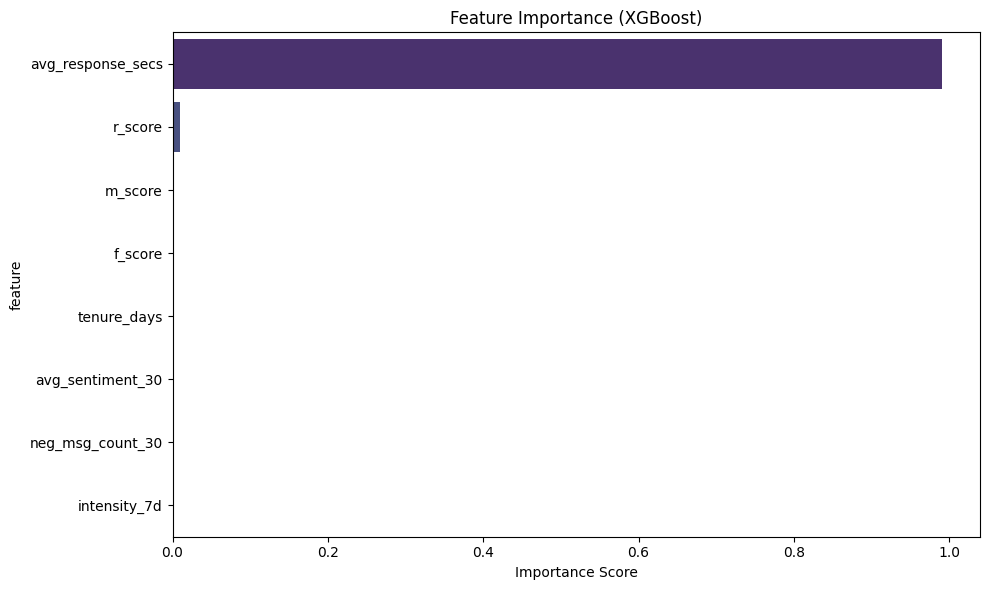


📊 Feature Importance:
             feature  importance
6  avg_response_secs    0.990054
0            r_score    0.009931
2            m_score    0.000015
1            f_score    0.000000
3        tenure_days    0.000000
4   avg_sentiment_30    0.000000
5   neg_msg_count_30    0.000000
7       intensity_7d    0.000000


In [29]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n📊 Feature Importance:")
print(feature_importance)

## 9. SHAP Explainability

In [30]:
# Create SHAP explainer
print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values untuk test set
shap_values = explainer.shap_values(X_test)

print("✅ SHAP explainer created!")

Creating SHAP explainer...
✅ SHAP explainer created!


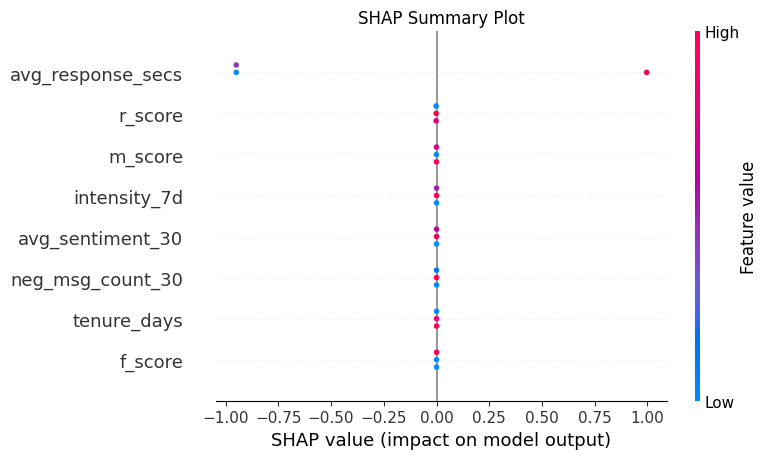

In [31]:
# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLUMNS, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

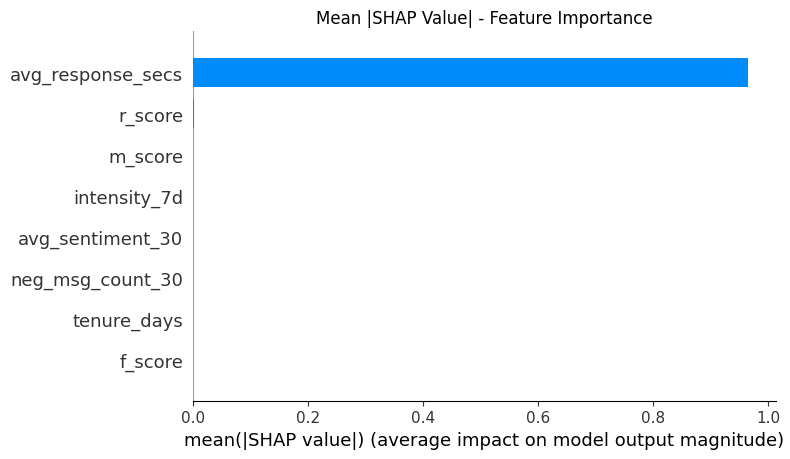

In [32]:
# SHAP Bar Plot (Mean absolute SHAP values)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLUMNS, plot_type='bar', show=False)
plt.title('Mean |SHAP Value| - Feature Importance')
plt.tight_layout()
plt.show()


🔍 Explanation for Customer at index 0:
Actual: Active
Predicted probability of churn: 0.2776


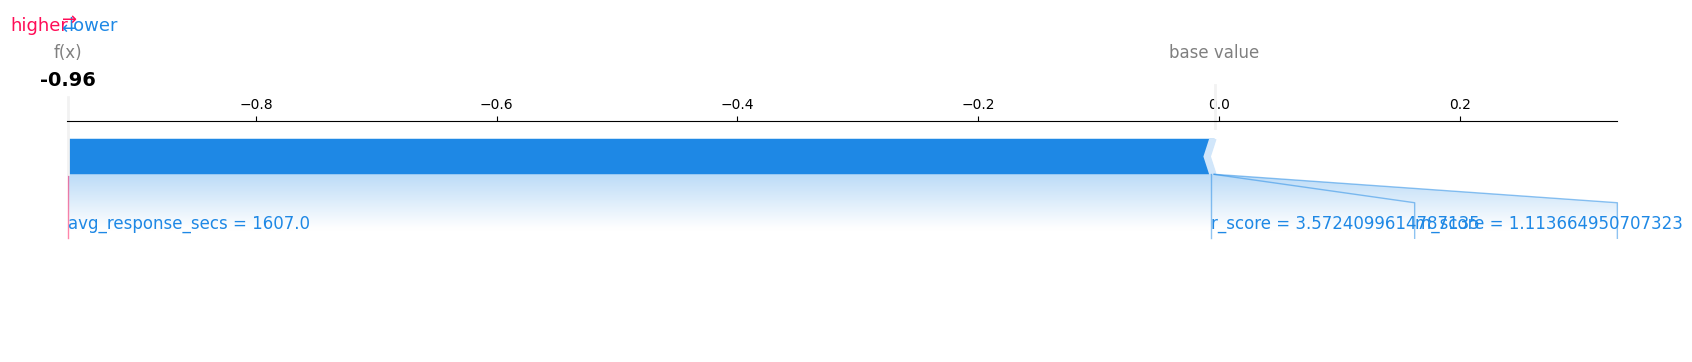

In [33]:
# Individual prediction explanation (sample)
sample_idx = 0  # Index customer yang ingin dijelaskan

print(f"\n🔍 Explanation for Customer at index {sample_idx}:")
print(f"Actual: {'Churned' if y_test.iloc[sample_idx] == 1 else 'Active'}")
print(f"Predicted probability of churn: {y_pred_proba[sample_idx]:.4f}")

# Force plot
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[sample_idx], X_test.iloc[sample_idx], 
               feature_names=FEATURE_COLUMNS, matplotlib=True)

## 10. Export Model untuk Production

Export model dan SHAP explainer ke folder `backend/models/` agar bisa digunakan oleh Flask backend.

In [34]:
import os

# Path ke folder backend/models
MODEL_DIR = '../backend/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Paths
MODEL_PATH = os.path.join(MODEL_DIR, 'churn_model.pkl')
EXPLAINER_PATH = os.path.join(MODEL_DIR, 'shap_explainer.pkl')
SCALER_PATH = os.path.join(MODEL_DIR, 'scaler.pkl')
METADATA_PATH = os.path.join(MODEL_DIR, 'model_metadata.pkl')

print(f"Model directory: {os.path.abspath(MODEL_DIR)}")

Model directory: d:\coolyeah\Skripsi\Customer Analitycs (Mamina)\backend\models


In [35]:
# Save XGBoost Model
print("Saving XGBoost model...")
joblib.dump(xgb_model, MODEL_PATH)
print(f"✅ Model saved to: {MODEL_PATH}")

# Save SHAP Explainer
print("\nSaving SHAP explainer...")
joblib.dump(explainer, EXPLAINER_PATH)
print(f"✅ Explainer saved to: {EXPLAINER_PATH}")

# Save Scaler
print("\nSaving scaler...")
joblib.dump(scaler, SCALER_PATH)
print(f"✅ Scaler saved to: {SCALER_PATH}")

Saving XGBoost model...
✅ Model saved to: ../backend/models\churn_model.pkl

Saving SHAP explainer...
✅ Explainer saved to: ../backend/models\shap_explainer.pkl

Saving scaler...
✅ Scaler saved to: ../backend/models\scaler.pkl


In [36]:
# Save Model Metadata
# Handle jika test set tidak ada churn (data kecil)
try:
    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'accuracy': float(accuracy_score(y_test, y_pred)),
        'precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred, zero_division=0)),
        'f1_score': float(f1_score(y_test, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_pred_proba)) if len(np.unique(y_test)) > 1 else 0.5
    }
except Exception as e:
    print(f"⚠️ Metrics calculation warning: {e}")
    metrics = {'note': 'Metrics not available - small dataset'}

metadata = {
    'feature_columns': FEATURE_COLUMNS,
    'training_date': datetime.now().isoformat(),
    'n_samples': len(df),
    'churn_rate': float(df['churn'].mean()),
    'model_type': 'XGBClassifier',
    'metrics': metrics,
    'hyperparameters': {
        'n_estimators': 100,
        'max_depth': 5,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8
    }
}

joblib.dump(metadata, METADATA_PATH)
print(f"\n✅ Metadata saved to: {METADATA_PATH}")
print("\nMetadata:")
for key, value in metadata.items():
    print(f"  {key}: {value}")


✅ Metadata saved to: ../backend/models\model_metadata.pkl

Metadata:
  feature_columns: ['r_score', 'f_score', 'm_score', 'tenure_days', 'avg_sentiment_30', 'neg_msg_count_30', 'avg_response_secs', 'intensity_7d']
  training_date: 2025-12-24T03:40:14.765327
  n_samples: 10
  churn_rate: 0.2
  model_type: XGBClassifier
  metrics: {'accuracy': 0.6666666666666666, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0, 'roc_auc': 0.5}
  hyperparameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}


In [37]:
# Verify saved files
print("\n📁 Saved Files:")
for filename in os.listdir(MODEL_DIR):
    filepath = os.path.join(MODEL_DIR, filename)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    print(f"  {filename}: {size_mb:.2f} MB")


📁 Saved Files:
  churn_model.pkl: 0.07 MB
  features.json: 0.00 MB
  model_metadata.pkl: 0.00 MB
  README.md: 0.00 MB
  scaler.pkl: 0.00 MB
  shap_explainer.pkl: 0.14 MB


## 11. Test Load Model (Simulasi Production)

In [38]:
# Simulasi loading model seperti di Flask
print("Loading model untuk testing...")

loaded_model = joblib.load(MODEL_PATH)
loaded_explainer = joblib.load(EXPLAINER_PATH)
loaded_metadata = joblib.load(METADATA_PATH)

print("✅ Model loaded successfully!")
print(f"Model type: {type(loaded_model).__name__}")
print(f"Feature columns: {loaded_metadata['feature_columns']}")

Loading model untuk testing...
✅ Model loaded successfully!
Model type: XGBClassifier
Feature columns: ['r_score', 'f_score', 'm_score', 'tenure_days', 'avg_sentiment_30', 'neg_msg_count_30', 'avg_response_secs', 'intensity_7d']


In [39]:
# Test prediction dengan sample data
sample_features = X_test.iloc[0:5]
sample_predictions = loaded_model.predict_proba(sample_features)[:, 1]

print("\n🧪 Sample Predictions:")
for i, (idx, row) in enumerate(sample_features.iterrows()):
    actual = 'Churned' if y_test.iloc[i] == 1 else 'Active'
    prob = sample_predictions[i]
    predicted = 'Churned' if prob > 0.5 else 'Active'
    print(f"  Sample {i+1}: Actual={actual}, Predicted={predicted}, Prob={prob:.4f}")


🧪 Sample Predictions:
  Sample 1: Actual=Active, Predicted=Active, Prob=0.2776
  Sample 2: Actual=Active, Predicted=Active, Prob=0.2776
  Sample 3: Actual=Active, Predicted=Churned, Prob=0.7291


In [40]:
# Test SHAP explanation
sample_shap = loaded_explainer.shap_values(sample_features.iloc[0:1])

print("\n🔍 SHAP Explanation for Sample 1:")
for feat, shap_val in zip(FEATURE_COLUMNS, sample_shap[0]):
    direction = "↑ churn" if shap_val > 0 else "↓ churn"
    print(f"  {feat}: {shap_val:+.4f} ({direction})")


🔍 SHAP Explanation for Sample 1:
  r_score: -0.0021 (↓ churn)
  f_score: +0.0000 (↓ churn)
  m_score: -0.0006 (↓ churn)
  tenure_days: +0.0000 (↓ churn)
  avg_sentiment_30: +0.0000 (↓ churn)
  neg_msg_count_30: +0.0000 (↓ churn)
  avg_response_secs: -0.9499 (↓ churn)
  intensity_7d: +0.0000 (↓ churn)


---

## ✅ Training Complete!

Model telah disimpan di folder `backend/models/`:

| File | Deskripsi |
|------|-----------|
| `churn_model.pkl` | XGBoost model untuk prediksi |
| `shap_explainer.pkl` | SHAP explainer untuk interpretability |
| `scaler.pkl` | StandardScaler untuk feature scaling |
| `model_metadata.pkl` | Metadata training (metrics, hyperparameters) |

**Next Steps:**
1. Jalankan Flask backend
2. Test endpoint `/api/v1/predictions/` untuk melihat prediksi
3. Test endpoint `/api/v1/predictions/<customer_id>/explain` untuk SHAP explanation